CHARGEMENT DES DONNÉES ET DU MODÈLE
✅ Data shape: (17313, 23)
✅ Model loaded: Random Forest
✅ Features used: 14
✅ Target distribution: 
target
0    0.622249
1    0.377751
Name: proportion, dtype: float64

PRÉPARATION DES DONNÉES
📅 Training period: 2024-02-16 10:00:00+00:00 to 2025-09-15 12:00:00+00:00
📅 Test period: 2025-09-15 13:00:00+00:00 to 2026-02-13 06:00:00+00:00
📊 Training samples: 13850
📊 Test samples: 3463

GÉNÉRATION DES PRÉDICTIONS
🎯 Signal threshold: 0.55
📈 Signal distribution:
signal
0    3169
1     294

📊 Signal proportions:
signal
0    0.915103
1    0.084897

CALCUL DES RETURNS
💰 Transaction cost: 0.1% per trade
🔄 Number of trades: 366
💸 Total costs: 36.6000%

MÉTRIQUES DE PERFORMANCE
📈 Final Cumulative Return: -62.42%
📈 Buy & Hold Return: -42.21%
📊 Outperformance: -20.21%
📊 Sharpe Ratio: -2.5796
📉 Max Drawdown: -62.42%
🎯 Hit Ratio: 31.97%
📊 Number of Trades: 294
📊 Annualized Return: -6.87%
📊 Volatility (annual): 3.51%
📊 Calmar Ratio: -0.1101

ANALYSE DÉTAILLÉE DES TRAD

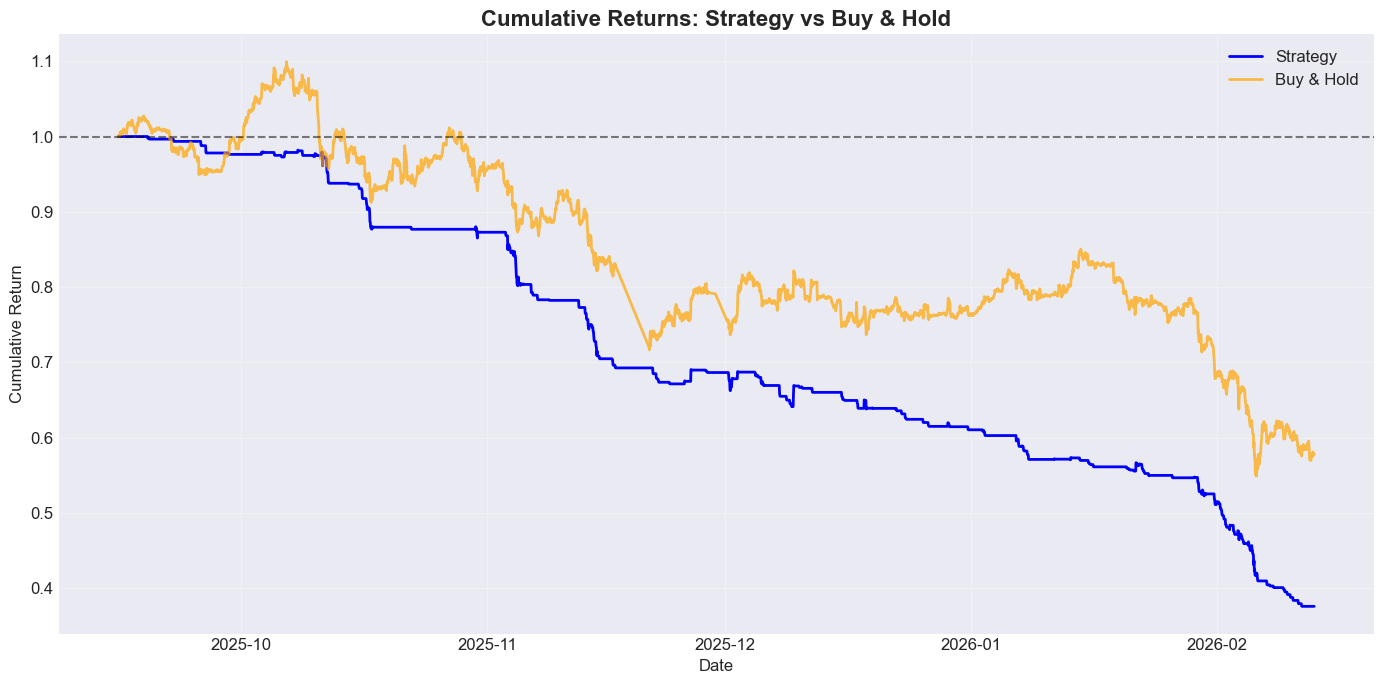

✅ Graphique sauvegardé: reports/figures/cumulative_returns.png


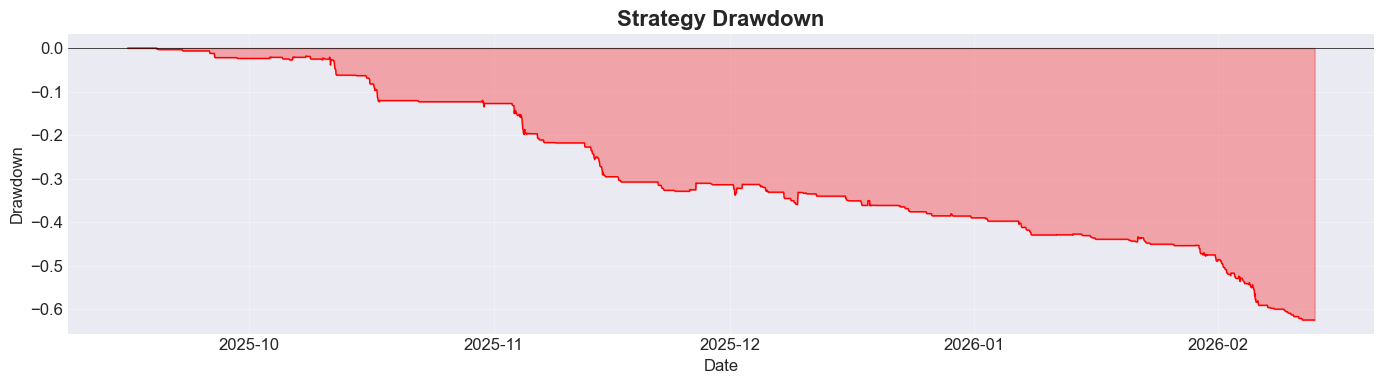

✅ Graphique sauvegardé: reports/figures/drawdown.png

ANALYSE MENSUELLE


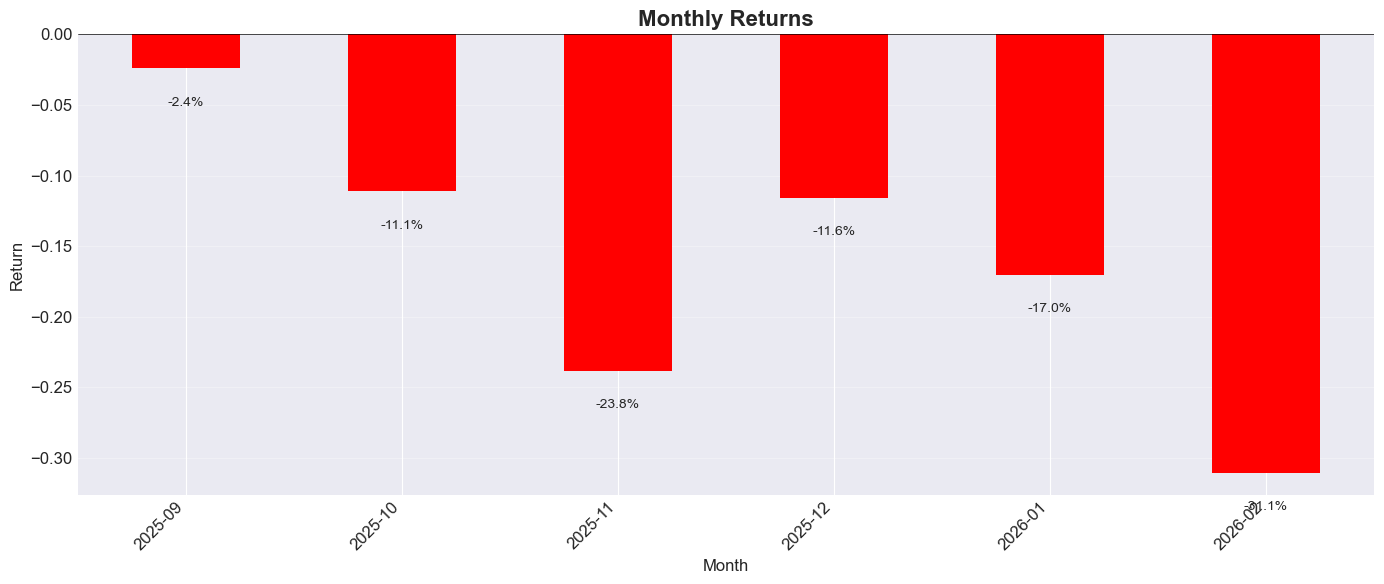

✅ Graphique sauvegardé: reports/figures/monthly_returns.png

📅 Monthly Returns:
   2025-09: -2.39%
   2025-10: -11.12%
   2025-11: -23.83%
   2025-12: -11.57%
   2026-01: -17.03%
   2026-02: -31.06%


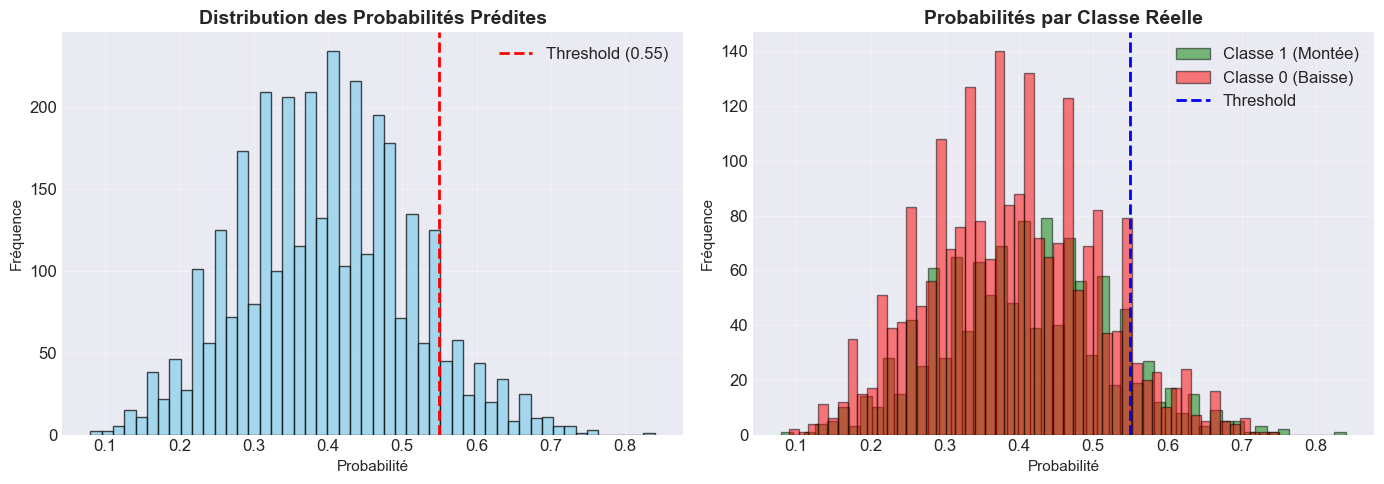

✅ Graphique sauvegardé: reports/figures/probability_distribution.png


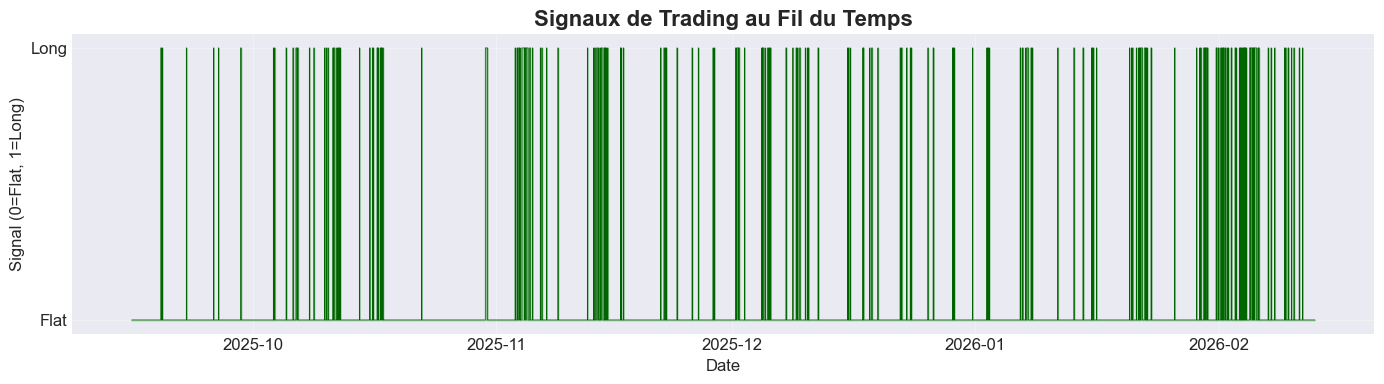

✅ Graphique sauvegardé: reports/figures/signals_over_time.png

SAUVEGARDE DES RÉSULTATS
✅ Résultats détaillés sauvegardés: ..\reports\backtest_results.csv
✅ Résumé des métriques sauvegardé: ..\reports\metrics_summary.csv

✅ BACKTEST TERMINÉ AVEC SUCCÈS


In [1]:
# %% [markdown]
# # 04 - Backtesting
# ## Strategy backtesting and performance metrics

# %%
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from src import utils, config

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

# %%
# Load data and best model
print("="*50)
print("CHARGEMENT DES DONNÉES ET DU MODÈLE")
print("="*50)

df = pd.read_csv(config.FEATURES_DATA_PATH)
model = utils.load_model(config.RF_MODEL_PATH)

print(f"✅ Data shape: {df.shape}")
print(f"✅ Model loaded: Random Forest")
print(f"✅ Features used: {len(config.FEATURES)}")
print(f"✅ Target distribution: \n{df[config.TARGET].value_counts(normalize=True)}")

# %%
# Prepare data
print("\n" + "="*50)
print("PRÉPARATION DES DONNÉES")
print("="*50)

X = df[config.FEATURES]
y = df[config.TARGET]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Chronological split
train_size = int(len(df) * (1 - config.TEST_SIZE))
X_test = X_scaled[train_size:]
df_test = df.iloc[train_size:].copy().reset_index(drop=True)

print(f"📅 Training period: {df['Datetime'].iloc[0]} to {df['Datetime'].iloc[train_size-1]}")
print(f"📅 Test period: {df['Datetime'].iloc[train_size]} to {df['Datetime'].iloc[-1]}")
print(f"📊 Training samples: {train_size}")
print(f"📊 Test samples: {len(df_test)}")

# %%
# Generate predictions
print("\n" + "="*50)
print("GÉNÉRATION DES PRÉDICTIONS")
print("="*50)

y_proba = model.predict_proba(X_test)[:, 1]
df_test['signal'] = (y_proba > config.SIGNAL_THRESHOLD).astype(int)
df_test['prediction'] = df_test['signal']  # Alias pour plus de clarté

print(f"🎯 Signal threshold: {config.SIGNAL_THRESHOLD}")
print(f"📈 Signal distribution:")
print(df_test['signal'].value_counts().to_string())
print(f"\n📊 Signal proportions:")
print(df_test['signal'].value_counts(normalize=True).to_string())

# %%
# Calculate strategy returns
print("\n" + "="*50)
print("CALCUL DES RETURNS")
print("="*50)

df_test['strategy_return'] = df_test['returns'] * df_test['signal']

# Apply transaction costs
df_test['position_change'] = df_test['signal'].diff().abs().fillna(0)
df_test['cost'] = df_test['position_change'] * config.TRANSACTION_COST
df_test['strategy_net'] = df_test['strategy_return'] - df_test['cost']
df_test['cum_return'] = (1 + df_test['strategy_net']).cumprod()

# Buy & Hold for comparison
df_test['bh_return'] = (1 + df_test['returns']).cumprod()

print(f"💰 Transaction cost: {config.TRANSACTION_COST:.1%} per trade")
print(f"🔄 Number of trades: {df_test['position_change'].sum():.0f}")
print(f"💸 Total costs: {df_test['cost'].sum():.4%}")

# %%
# Calculate performance metrics
print("\n" + "="*50)
print("MÉTRIQUES DE PERFORMANCE")
print("="*50)

sharpe = utils.calculate_sharpe_ratio(df_test['strategy_net'])
max_dd = utils.calculate_max_drawdown(df_test['cum_return'])
trades = df_test[df_test['signal'] == 1]
hit_ratio = utils.calculate_hit_ratio(trades['returns'])

# Additional metrics
total_return = df_test['cum_return'].iloc[-1] - 1
bh_total_return = df_test['bh_return'].iloc[-1] - 1
annual_return = (1 + total_return) ** (252/len(df_test)) - 1
volatility = df_test['strategy_net'].std() * np.sqrt(252)
calmar_ratio = annual_return / abs(max_dd) if max_dd != 0 else 0

print(f"📈 Final Cumulative Return: {total_return:.2%}")
print(f"📈 Buy & Hold Return: {bh_total_return:.2%}")
print(f"📊 Outperformance: {(total_return - bh_total_return):.2%}")
print(f"📊 Sharpe Ratio: {sharpe:.4f}")
print(f"📉 Max Drawdown: {max_dd:.2%}")
print(f"🎯 Hit Ratio: {hit_ratio:.2%}")
print(f"📊 Number of Trades: {len(trades)}")
print(f"📊 Annualized Return: {annual_return:.2%}")
print(f"📊 Volatility (annual): {volatility:.2%}")
print(f"📊 Calmar Ratio: {calmar_ratio:.4f}")

# %%
# Detailed trading analysis
print("\n" + "="*50)
print("ANALYSE DÉTAILLÉE DES TRADES")
print("="*50)

winning_trades = trades[trades['returns'] > 0]
losing_trades = trades[trades['returns'] < 0]

print(f"✅ Winning Trades: {len(winning_trades)} ({len(winning_trades)/len(trades)*100:.1f}%)")
print(f"❌ Losing Trades: {len(losing_trades)} ({len(losing_trades)/len(trades)*100:.1f}%)")
print(f"💹 Average Win: {winning_trades['returns'].mean():.4%}")
print(f"📉 Average Loss: {losing_trades['returns'].mean():.4%}")

if len(losing_trades) > 0:
    profit_factor = abs(winning_trades['returns'].sum() / losing_trades['returns'].sum())
    print(f"💰 Profit Factor: {profit_factor:.2f}")

# %%
# Confusion Matrix
print("\n" + "="*50)
print("MATRICE DE CONFUSION")
print("="*50)

y_test_actual = y.iloc[train_size:].values
cm = confusion_matrix(y_test_actual, df_test['signal'])

print("          Prédit")
print("          0     1")
print(f"Réel 0:  {cm[0,0]:5d} {cm[0,1]:5d}")
print(f"     1:  {cm[1,0]:5d} {cm[1,1]:5d}")

accuracy = (cm[0,0] + cm[1,1]) / cm.sum()
precision = cm[1,1] / (cm[0,1] + cm[1,1]) if (cm[0,1] + cm[1,1]) > 0 else 0
recall = cm[1,1] / (cm[1,0] + cm[1,1]) if (cm[1,0] + cm[1,1]) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n📊 Accuracy: {accuracy:.2%}")
print(f"📊 Precision: {precision:.2%}")
print(f"📊 Recall: {recall:.2%}")
print(f"📊 F1-Score: {f1_score:.2%}")

# %%
# Plot 1: Cumulative Returns
print("\n" + "="*50)
print("GÉNÉRATION DES GRAPHIQUES")
print("="*50)

plt.figure(figsize=(14, 7))
plt.plot(pd.to_datetime(df_test['Datetime']), df_test['cum_return'], 
         label='Strategy', linewidth=2, color='blue')
plt.plot(pd.to_datetime(df_test['Datetime']), df_test['bh_return'], 
         label='Buy & Hold', linewidth=2, alpha=0.7, color='orange')
plt.title('Cumulative Returns: Strategy vs Buy & Hold', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.axhline(y=1, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(config.FIGURES_PATH, 'cumulative_returns.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Graphique sauvegardé: {os.path.join(config.FIGURES_PATH, 'cumulative_returns.png')}")

# %%
# Plot 2: Drawdown
plt.figure(figsize=(14, 4))
cum_max = df_test['cum_return'].cummax()
drawdown = df_test['cum_return'] / cum_max - 1

plt.fill_between(pd.to_datetime(df_test['Datetime']), drawdown, 0, color='red', alpha=0.3)
plt.plot(pd.to_datetime(df_test['Datetime']), drawdown, color='red', linewidth=1)
plt.title('Strategy Drawdown', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Drawdown', fontsize=12)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.savefig(os.path.join(config.FIGURES_PATH, 'drawdown.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Graphique sauvegardé: {os.path.join(config.FIGURES_PATH, 'drawdown.png')}")

# %%
# Plot 3: Monthly Returns (with timezone fix)
print("\n" + "="*50)
print("ANALYSE MENSUELLE")
print("="*50)

# Fix timezone warning
df_test['Datetime'] = pd.to_datetime(df_test['Datetime'])
if df_test['Datetime'].dt.tz is not None:
    df_test['Datetime'] = df_test['Datetime'].dt.tz_localize(None)

df_test['year_month'] = df_test['Datetime'].dt.to_period('M')
monthly_returns = df_test.groupby('year_month')['strategy_net'].sum()

plt.figure(figsize=(14, 6))
colors = ['green' if x > 0 else 'red' for x in monthly_returns.values]
monthly_returns.plot(kind='bar', color=colors)
plt.title('Monthly Returns', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Return', fontsize=12)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(monthly_returns.values):
    plt.text(i, v + (0.01 if v > 0 else -0.02), f'{v:.1%}', 
             ha='center', va='bottom' if v > 0 else 'top', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(config.FIGURES_PATH, 'monthly_returns.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Graphique sauvegardé: {os.path.join(config.FIGURES_PATH, 'monthly_returns.png')}")

# Print monthly returns table
print("\n📅 Monthly Returns:")
for month, ret in monthly_returns.items():
    print(f"   {month}: {ret:+.2%}")

# %%
# Plot 4: Probability Distribution
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(y_proba, bins=50, alpha=0.7, edgecolor='black', color='skyblue')
plt.axvline(x=config.SIGNAL_THRESHOLD, color='red', linestyle='--', 
            linewidth=2, label=f'Threshold ({config.SIGNAL_THRESHOLD})')
plt.title('Distribution des Probabilités Prédites', fontsize=14, fontweight='bold')
plt.xlabel('Probabilité', fontsize=11)
plt.ylabel('Fréquence', fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(y_proba[y_test_actual == 1], bins=50, alpha=0.5, label='Classe 1 (Montée)', 
         color='green', edgecolor='black')
plt.hist(y_proba[y_test_actual == 0], bins=50, alpha=0.5, label='Classe 0 (Baisse)', 
         color='red', edgecolor='black')
plt.axvline(x=config.SIGNAL_THRESHOLD, color='blue', linestyle='--', 
            linewidth=2, label='Threshold')
plt.title('Probabilités par Classe Réelle', fontsize=14, fontweight='bold')
plt.xlabel('Probabilité', fontsize=11)
plt.ylabel('Fréquence', fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(config.FIGURES_PATH, 'probability_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Graphique sauvegardé: {os.path.join(config.FIGURES_PATH, 'probability_distribution.png')}")

# %%
# Plot 5: Signal Distribution Over Time
plt.figure(figsize=(14, 4))
plt.fill_between(pd.to_datetime(df_test['Datetime']), 0, df_test['signal'], 
                 alpha=0.3, color='green', step='post')
plt.plot(pd.to_datetime(df_test['Datetime']), df_test['signal'], 
         color='darkgreen', linewidth=0.5, drawstyle='steps-post')
plt.title('Signaux de Trading au Fil du Temps', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Signal (0=Flat, 1=Long)', fontsize=12)
plt.yticks([0, 1], ['Flat', 'Long'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(config.FIGURES_PATH, 'signals_over_time.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Graphique sauvegardé: {os.path.join(config.FIGURES_PATH, 'signals_over_time.png')}")

# %%
# Save test results
print("\n" + "="*50)
print("SAUVEGARDE DES RÉSULTATS")
print("="*50)

# Create reports directory if it doesn't exist
os.makedirs(os.path.join('..', 'reports'), exist_ok=True)

# Save detailed results
results_df = df_test[['Datetime', 'returns', 'signal', 'strategy_return', 
                      'strategy_net', 'cum_return', 'bh_return']].copy()
results_df.to_csv(os.path.join('..', 'reports', 'backtest_results.csv'), index=False)

# Save summary metrics
metrics_summary = pd.DataFrame({
    'Metric': ['Total Return', 'Buy & Hold Return', 'Sharpe Ratio', 'Max Drawdown', 
               'Hit Ratio', 'Number of Trades', 'Annualized Return', 'Volatility', 
               'Calmar Ratio', 'Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Value': [f"{total_return:.2%}", f"{bh_total_return:.2%}", f"{sharpe:.4f}", 
              f"{max_dd:.2%}", f"{hit_ratio:.2%}", f"{len(trades)}", 
              f"{annual_return:.2%}", f"{volatility:.2%}", f"{calmar_ratio:.4f}",
              f"{accuracy:.2%}", f"{precision:.2%}", f"{recall:.2%}", f"{f1_score:.2%}"]
})
metrics_summary.to_csv(os.path.join('..', 'reports', 'metrics_summary.csv'), index=False)

print(f"✅ Résultats détaillés sauvegardés: {os.path.join('..', 'reports', 'backtest_results.csv')}")
print(f"✅ Résumé des métriques sauvegardé: {os.path.join('..', 'reports', 'metrics_summary.csv')}")

# %%
print("\n" + "="*50)
print("✅ BACKTEST TERMINÉ AVEC SUCCÈS")
print("="*50)